# Differential gene expression across condition combinations

In clinical data analysis, we often need to run differential expression (DE) across combinations of covariates: for example, comparing COVID-19 patients to healthy volunteers within each sex group to understand whether the transcriptional response to disease differs between men and women.

`patpy` provides two tools for this, which address different statistical questions:

1. `ConditionComparison`: pairwise, one model per contrast

Fits an independent DE model on the subset of samples belonging to each pair of groups. Uses `model.compare_groups()` internally and works with any pertpy DE method (PyDESeq2, EdgeR, Milo, …).

Each contrast is tested in isolation: the model for "COVID females vs HV females" sees only those ~15 donors. Dispersion is estimated from that subset alone.

**Use when:** condition combinations may be missing; you need to screen many axes quickly; you need a method other than EdgeR/PyDESeq2.

2. `FactorialDE`: single model, all samples

Fits **one model on all donors simultaneously**. Pairwise contrasts and interaction tests are then extracted algebraically from that single fitted model. Because dispersion (EdgeR) or size factors (PyDESeq2) are estimated from all groups at once, tests are more stable and more powerful, especially for lowly expressed genes.

Two encodings:

**`"group"`** — design `~ 0 + Source_Sex` (EdgeR) or `~ Source_Sex` (PyDESeq2).  
One coefficient per condition combination. Any pairwise contrast is a linear combination of two coefficients from the same fitted model. Produces the same contrasts as `ConditionComparison` but with shared dispersion across all groups.

**`"interaction"`** — design `~ Source + Sex + Source:Sex`.  
Adds an explicit interaction term. The `Source:Sex` coefficient directly and formally tests: *is the COVID-19 transcriptional response significantly different between men and women?* This cannot be answered by pairwise comparisons alone.

**Use when:** all condition combinations are present; you want maximum power; you need the interaction test.




We use the **COMBAT COVID-19 cohort** (PBMC from ~140 donors) as a real-world example, following the same pseudobulk pipeline as the [pertpy DE tutorial](https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/differential_gene_expression.html).

## Install

```bash
pip install patpy pertpy pydeseq2
# For EdgeR (requires R):
pip install rpy2
# In R: BiocManager::install("edgeR")
```

## Import packages

In [1]:
import pertpy as pt
import scanpy as sc
import pandas as pd
import numpy as np
import warnings

import patpy
import patpy.tl.condition_comparison as ptc
import patpy.tl.factorial_comparison as ptf

warnings.filterwarnings("ignore")

/lustre/groups/ml01/workspace/lucas.arnoldt/cellink_patpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
patpy.__version__

'0.12.1'

## Load the COMBAT dataset

The dataset contains 836k cells x 20,807 genes from ~140 PBMC donors spanning healthy volunteers (HV) and COVID-19 patients at various severity levels.

In [3]:
ADATA_PATH = "/home/icb/lucas.arnoldt/workspace/projects/patpy/COMBAT-CITESeq-DATA.h5ad"
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 836148 × 20807
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_H

## Set columns containing sample IDs, cell types and metadata

In [4]:
sample_id_col = "scRNASeq_sample_ID"       # per-donor identifier
cell_type_key = "Annotation_major_subset"  # broad cell type labels
source_col    = "Source"                   # COVID_SEV / HV
sex_col       = "Sex"                      # 0 = male, 1 = female

## Quality control

Remove donors with fewer than 100 cells.

In [5]:
adata = patpy.pp.filter_small_samples(
    adata, sample_key=sample_id_col, sample_size_threshold=100
)
print(f"{adata.obs[sample_id_col].nunique()} donors after QC filtering")
adata.layers["raw"] = adata.layers["raw"].todense()

2 samples removed: G05092-Ja005E-PBCa, S00030-Ja003E-PBCa
138 donors after QC filtering


## Subset to a manageable cohort

We keep only COVID-19 patients and healthy volunteers and sample up to 20 donors per source. Remove this cell to run on the full dataset.

In [6]:
adata = adata[adata.obs[source_col].isin(["COVID_SEV", "HV"])].copy()
adata.obs[sex_col] = adata.obs[sex_col].map({0: "male", 1: "female"})

rng = np.random.default_rng(42)
keep = []
for source, grp in adata.obs.groupby(source_col):
    donors = grp[sample_id_col].unique()
    sampled = rng.choice(donors, size=min(20, len(donors)), replace=False)
    keep.extend(sampled)

adata = adata[adata.obs[sample_id_col].isin(keep)].copy()
print(f"{adata.n_obs:,} cells | {adata.obs[sample_id_col].nunique()} donors")
adata.obs[[sample_id_col, source_col]].drop_duplicates()[source_col].value_counts()

214,842 cells | 30 donors


Source
COVID_SEV    20
HV           10
Name: count, dtype: int64

## Create pseudobulk profiles

DE models require integer counts aggregated at the donor level. We use `patpy.tl.Pseudobulk` for aggregation and `patpy.pp.extract_metadata` to build the donor-level obs DataFrame.

In [7]:
pb = patpy.tl.Pseudobulk(
    sample_key=sample_id_col,
    cell_group_key=cell_type_key,
    layer="raw",
)
pb.prepare_anndata(adata)
pb.calculate_distance_matrix(aggregate="sum")
print(f"sample_representation shape: {pb.sample_representation.shape}")
print(f"donors: {len(pb.samples)}")

sample_representation shape: (30, 20807)
donors: 30


In [8]:
donor_obs = patpy.pp.extract_metadata(
    adata, sample_key=sample_id_col, columns=[source_col, sex_col]
)
pdata = pb.to_adata(metadata=donor_obs)
pdata.var = adata.var

## Explore axes of variation

Before fitting any DE model it is useful to understand which covariates drive variance in the pseudobulk profiles. We run PCA and use `patpy.tl.associate_embedding_with_covariates` to test each PC against each clinical variable, then visualise with `patpy.pl.embedding_covariate_heatmap`.

This guides the choice of design formula and which contrasts are worth testing.

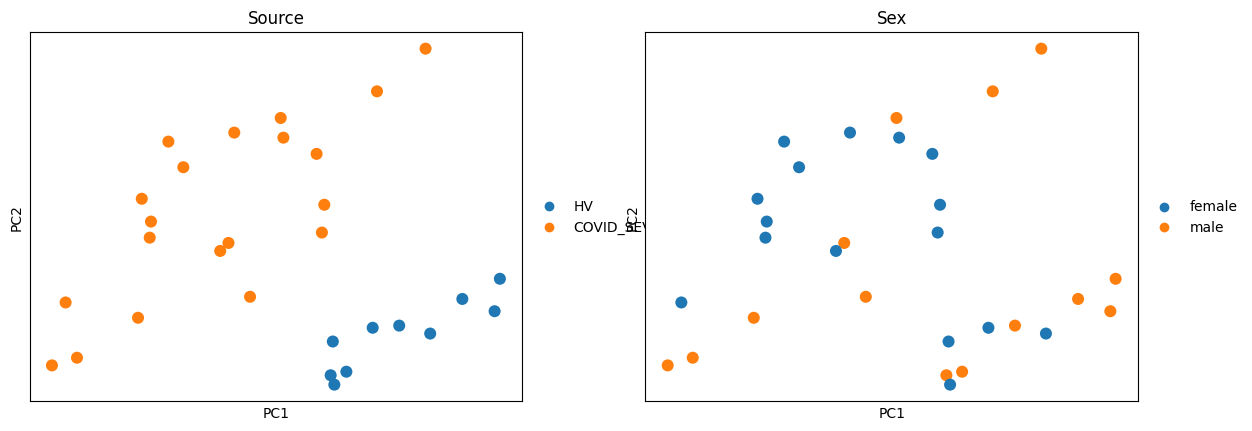

In [9]:
pdata_pca = pdata.copy()
sc.pp.normalize_total(pdata_pca, target_sum=1e4)
sc.pp.log1p(pdata_pca)
sc.pp.scale(pdata_pca, max_value=10)
sc.pp.pca(pdata_pca)
pdata.obsm["X_pca"] = pdata_pca.obsm["X_pca"]
sc.pl.pca(pdata_pca, color=[source_col, sex_col], ncols=2, size=300)

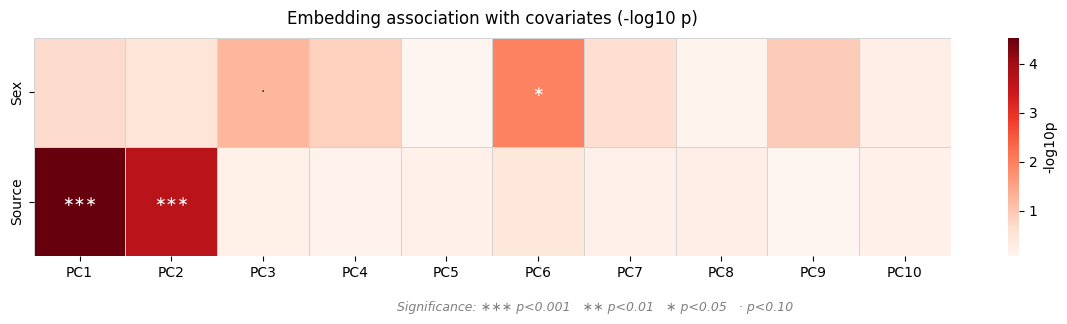

In [10]:
# Test which PCs are driven by each clinical covariate
assoc = patpy.tl.associate_embedding_with_covariates(
    pdata, covariates=[source_col, sex_col], obsm_key="X_pca", n_components=10,
)
patpy.pl.embedding_covariate_heatmap(assoc)

## Condition space

`ptc.build_condition_combinations` lists every *observed* combination of condition axes and `ptc.build_all_pairwise_contrasts` enumerates all pairs. This is a quick sanity check before launching any model fits.

In [11]:
condition_cols = [source_col, sex_col]
combos = ptc.build_condition_combinations(pdata, condition_cols)
print(f"{len(combos)} observed condition combinations:")
combos

4 observed condition combinations:


,Source,Sex,label
0,COVID_SEV,male,COVID_SEV_male
1,HV,male,HV_male
2,COVID_SEV,female,COVID_SEV_female
3,HV,female,HV_female


In [12]:
contrasts = ptc.build_all_pairwise_contrasts(pdata, condition_cols)
print(f"{len(contrasts)} pairwise contrasts:")
for c in contrasts:
    print(f"  {c['label']}")

6 pairwise contrasts:
  COVID_SEV_male_vs_HV_male
  COVID_SEV_male_vs_COVID_SEV_female
  COVID_SEV_male_vs_HV_female
  HV_male_vs_COVID_SEV_female
  HV_male_vs_HV_female
  COVID_SEV_female_vs_HV_female


## 1. ConditionComparison: pairwise, one model per contrast

Each contrast fits an independent model on the ~15 donors belonging to those two groups. `run_once` returns `(results_df, models)` where `models` maps each contrast label to a model instance for plotting.

### PyDESeq2

In [13]:
res_cc_deseq2, models_deseq2 = ptc.ConditionComparison.run_once(
    pt.tl.PyDESeq2, pdata, condition_cols=condition_cols,
)

res_cc_deseq2[res_cc_deseq2["adj_p_value"] < 0.05].groupby("contrast")["variable"].count().sort_values(ascending=False)

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 13.93 seconds.

Fitting dispersion trend curve...
... done in 0.42 seconds.

Fitting MAP dispersions...
... done in 17.81 seconds.

Fitting LFCs...
... done in 11.74 seconds.

Calculating cook's distance...
... done in 0.11 seconds.

Replacing 162 outlier genes.

Fitting dispersions...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.17 seconds.

Running Wald tests...
... done in 59.25 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.257261        0.638596  2.704208  0.236149  0.813317   
NOC2L             1301.177247        0.094372  0.111198  0.848677  0.396061   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15319.067933        0.120656  0.180509  0.668418  0.503866   
AB_CD224        205047.129847        0.497971  0.158971  3.132462  0.001733   
AB_c_Met         43838.260224        0.078896  0.163130  0.483640  0.628642   
AB_CD258_LIGHT   30073.626348        0.274918  0.196365  1.400034  0.161503   
AB_DR3_TRAMP     54924.487941       -0.001373  0.150129 -0.009143 

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 14.07 seconds.

Fitting dispersion trend curve...
... done in 0.41 seconds.

Fitting MAP dispersions...
... done in 23.33 seconds.

Fitting LFCs...
... done in 10.98 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 161 outlier genes.

Fitting dispersions...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Running Wald tests...
... done in 53.52 seconds.



...

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 12.37 seconds.

Fitting dispersion trend curve...
... done in 0.40 seconds.

Fitting MAP dispersions...
... done in 17.69 seconds.

Fitting LFCs...
... done in 9.44 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 52.23 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.161094       -0.218150  3.429169 -0.063616  0.949276   
NOC2L             1457.437279        0.008025  0.072268  0.111045  0.911581   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   17811.995772       -0.162549  0.120624 -1.347573  0.177796   
AB_CD224        212810.362686       -0.324465  0.170924 -1.898299  0.057657   
AB_c_Met         51331.924318       -0.128705  0.114996 -1.119209  0.263051   
AB_CD258_LIGHT   33068.168373       -0.192380  0.107632 -1.787390  0.073875   
AB_DR3_TRAMP     65395.739182       -0.075470  0.112482 -0.670949  0

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 13.66 seconds.

Fitting dispersion trend curve...
... done in 0.42 seconds.

Fitting MAP dispersions...
... done in 20.00 seconds.

Fitting LFCs...
... done in 11.18 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 124 outlier genes.

Fitting dispersions...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Running Wald tests...
... done in 52.82 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.501578        1.498871  1.903771  0.787317  0.431096   
NOC2L             1140.414076        0.052733  0.084487  0.624154  0.532527   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   13100.698970       -0.201278  0.120307 -1.673042  0.094319   
AB_CD224        211821.629447        0.255880  0.180603  1.416811  0.156538   
AB_c_Met         38107.199532       -0.156263  0.121557 -1.285508  0.198615   
AB_CD258_LIGHT   26119.231594       -0.084049  0.129068 -0.651197  0.514919   
AB_DR3_TRAMP     46912.388948       -0.181463  0.121083 -1.498663 

contrast
HV_male_vs_COVID_SEV_female           6316
COVID_SEV_female_vs_HV_female         4135
COVID_SEV_male_vs_HV_male             3641
COVID_SEV_male_vs_HV_female           2377
COVID_SEV_male_vs_COVID_SEV_female     231
HV_male_vs_HV_female                    70
Name: variable, dtype: int64

### EdgeR

Switch to EdgeR by changing a single argument. Everything else is identical. EdgeR requires R with the `edgeR` Bioconductor package installed.

In [14]:
res_cc_edger, models_edger = ptc.ConditionComparison.run_once(
    pt.tl.EdgeR, pdata, condition_cols=condition_cols,
)

res_cc_edger[res_cc_edger["adj_p_value"] < 0.05].groupby("contrast")["variable"].count().sort_values(ascending=False)

• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model


contrast
HV_male_vs_COVID_SEV_female           5801
COVID_SEV_female_vs_HV_female         3224
COVID_SEV_male_vs_HV_male             2650
COVID_SEV_male_vs_HV_female           1187
COVID_SEV_male_vs_COVID_SEV_female      37
HV_male_vs_HV_female                    21
Name: variable, dtype: int64

`ConditionComparison` stores the model class and default kwargs so you can run the same setup across multiple condition axes without repeating yourself. After each `run()` call, model instances are stored in `cc.models_` and accessible via the named plot wrappers (`plot_volcano`, `plot_fold_change`, `plot_multicomparison_fc`) or `cc.get_model(contrast_label)` for full control.

In [15]:
cc = ptc.ConditionComparison(pt.tl.PyDESeq2)
res_source_sex = cc.run(pdata, condition_cols=[source_col, sex_col])
res_source      = cc.run(pdata, condition_cols=[source_col])

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 13.56 seconds.

Fitting dispersion trend curve...
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 17.80 seconds.

Fitting LFCs...
... done in 10.85 seconds.

Calculating cook's distance...
... done in 0.10 seconds.

Replacing 162 outlier genes.

Fitting dispersions...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.22 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Running Wald tests...
... done in 53.39 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.257261        0.638596  2.704208  0.236149  0.813317   
NOC2L             1301.177247        0.094372  0.111198  0.848677  0.396061   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15319.067933        0.120656  0.180509  0.668418  0.503866   
AB_CD224        205047.129847        0.497971  0.158971  3.132462  0.001733   
AB_c_Met         43838.260224        0.078896  0.163130  0.483640  0.628642   
AB_CD258_LIGHT   30073.626348        0.274918  0.196365  1.400034  0.161503   
AB_DR3_TRAMP     54924.487941       -0.001373  0.150129 -0.009143 

Fitting size factors...
... done in 0.02 seconds.



...

Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.161094       -0.218150  3.429169 -0.063616  0.949276   
NOC2L             1457.437279        0.008025  0.072268  0.111045  0.911581   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   17811.995772       -0.162549  0.120624 -1.347573  0.177796   
AB_CD224        212810.362686       -0.324465  0.170924 -1.898299  0.057657   
AB_c_Met         51331.924318       -0.128705  0.114996 -1.119209  0.263051   
AB_CD258_LIGHT   33068.168373       -0.192380  0.107632 -1.787390  0.073875   
AB_DR3_TRAMP     65395.739182       -0.075470  0.112482 -0.670949  0

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 13.25 seconds.

Fitting dispersion trend curve...
... done in 0.38 seconds.

Fitting MAP dispersions...
... done in 17.36 seconds.

Fitting LFCs...
... done in 9.80 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 124 outlier genes.

Fitting dispersions...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Running Wald tests...
... done in 51.31 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.501578        1.498871  1.903771  0.787317  0.431096   
NOC2L             1140.414076        0.052733  0.084487  0.624154  0.532527   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   13100.698970       -0.201278  0.120307 -1.673042  0.094319   
AB_CD224        211821.629447        0.255880  0.180603  1.416811  0.156538   
AB_c_Met         38107.199532       -0.156263  0.121557 -1.285508  0.198615   
AB_CD258_LIGHT   26119.231594       -0.084049  0.129068 -0.651197  0.514919   
AB_DR3_TRAMP     46912.388948       -0.181463  0.121083 -1.498663 

Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 14.68 seconds.

Fitting dispersion trend curve...
... done in 0.51 seconds.

Fitting MAP dispersions...
... done in 19.74 seconds.

Fitting LFCs...
... done in 10.39 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 252 outlier genes.

Fitting dispersions...
... done in 0.28 seconds.

Fitting MAP dispersions...
... done in 0.31 seconds.

Fitting LFCs...
... done in 0.20 seconds.

Running Wald tests...
... done in 51.61 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.396043        1.248338  1.305570  0.956163  0.338990   
NOC2L             1212.810770        0.067816  0.061259  1.107030  0.268281   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   14104.676718       -0.039824  0.107165 -0.371613  0.710181   
AB_CD224        209277.179155        0.409534  0.120222  3.406467  0.000658   
AB_c_Met         40707.871349       -0.036795  0.098071 -0.375191  0.707518   
AB_CD258_LIGHT   27915.251432        0.097523  0.116619  0.836254  0.403012   
AB_DR3_TRAMP     50528.479383       -0.093938  0.091834 -1.022908 

You can restrict to a biologically motivated subset of contrasts. Here, only comparisons against the HV reference:

In [16]:
all_contrasts = ptc.build_all_pairwise_contrasts(pdata, condition_cols)
vs_hv = [c for c in all_contrasts if "HV" in c["group"] or "HV" in c["baseline"]]

res_vs_hv, _ = ptc.ConditionComparison.run_once(
    pt.tl.PyDESeq2, pdata, condition_cols=condition_cols, subset_contrasts=vs_hv,
)
res_vs_hv["contrast"].unique()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 13.11 seconds.

Fitting dispersion trend curve...
... done in 0.38 seconds.

Fitting MAP dispersions...
... done in 17.20 seconds.

Fitting LFCs...
... done in 9.92 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 162 outlier genes.

Fitting dispersions...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Running Wald tests...
... done in 51.96 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.257261        0.638596  2.704208  0.236149  0.813317   
NOC2L             1301.177247        0.094372  0.111198  0.848677  0.396061   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15319.067933        0.120656  0.180509  0.668418  0.503866   
AB_CD224        205047.129847        0.497971  0.158971  3.132462  0.001733   
AB_c_Met         43838.260224        0.078896  0.163130  0.483640  0.628642   
AB_CD258_LIGHT   30073.626348        0.274918  0.196365  1.400034  0.161503   
AB_DR3_TRAMP     54924.487941       -0.001373  0.150129 -0.009143 

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 13.00 seconds.

Fitting dispersion trend curve...
... done in 0.38 seconds.

Fitting MAP dispersions...
... done in 17.07 seconds.

Fitting LFCs...
... done in 10.56 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 123 outlier genes.

Fitting dispersions...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Running Wald tests...
... done in 52.11 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.304920        0.413179  2.795188  0.147818  0.882486   
NOC2L             1275.680812        0.094984  0.141383  0.671824  0.501696   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15661.234430       -0.046817  0.227499 -0.205790  0.836955   
AB_CD224        220335.647664        0.167137  0.180218  0.927415  0.353711   
AB_c_Met         44364.190769       -0.055211  0.201932 -0.273415  0.784534   
AB_CD258_LIGHT   31169.337939        0.077529  0.240061  0.322956  0.746729   
AB_DR3_TRAMP     54636.606110       -0.082354  0.184598 -0.446130 

...

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 12.30 seconds.

Fitting dispersion trend curve...
... done in 0.40 seconds.

Fitting MAP dispersions...
... done in 16.19 seconds.

Fitting LFCs...
... done in 9.16 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 53.22 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.161094       -0.218150  3.429169 -0.063616  0.949276   
NOC2L             1457.437279        0.008025  0.072268  0.111045  0.911581   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   17811.995772       -0.162549  0.120624 -1.347573  0.177796   
AB_CD224        212810.362686       -0.324465  0.170924 -1.898299  0.057657   
AB_c_Met         51331.924318       -0.128705  0.114996 -1.119209  0.263051   
AB_CD258_LIGHT   33068.168373       -0.192380  0.107632 -1.787390  0.073875   
AB_DR3_TRAMP     65395.739182       -0.075470  0.112482 -0.670949  0

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 13.26 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 19.67 seconds.

Fitting LFCs...
... done in 9.96 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 124 outlier genes.

Fitting dispersions...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Running Wald tests...
... done in 52.89 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.501578        1.498871  1.903771  0.787317  0.431096   
NOC2L             1140.414076        0.052733  0.084487  0.624154  0.532527   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   13100.698970       -0.201278  0.120307 -1.673042  0.094319   
AB_CD224        211821.629447        0.255880  0.180603  1.416811  0.156538   
AB_c_Met         38107.199532       -0.156263  0.121557 -1.285508  0.198615   
AB_CD258_LIGHT   26119.231594       -0.084049  0.129068 -0.651197  0.514919   
AB_DR3_TRAMP     46912.388948       -0.181463  0.121083 -1.498663 

array(['COVID_SEV_male_vs_HV_male', 'COVID_SEV_male_vs_HV_female',
       'HV_male_vs_COVID_SEV_female', 'HV_male_vs_HV_female',
       'COVID_SEV_female_vs_HV_female'], dtype=object)

Most interesting are the within-sex disease comparisons (`COVID_SEV_female_vs_HV_female` and `COVID_SEV_male_vs_HV_male`): These two contrasts isolate the COVID-19 effect while holding sex constant. They are the most interpretable biologically. The contrast with the most DE genes is `HV_male_vs_COVID_SEV_female`. This is expected: it conflates two orthogonal biological signals (disease status *and* sex) so genes driving both effects are captured simultaneously. The contrast with the fewest DE genes (`HV_male_vs_HV_female`) reflects pure sex differences in healthy individuals. Comparing the DE gene counts across these two contrasts tells us whether the transcriptional response to COVID-19 is stronger in one sex than the other.

### Volcano plots: within-sex disease contrasts

We visualise the two within-sex disease contrasts side-by-side. If the response is sex-dimorphic, we expect different genes or different effect sizes between the two plots.

NaNs encountered, dropping rows with NaNs


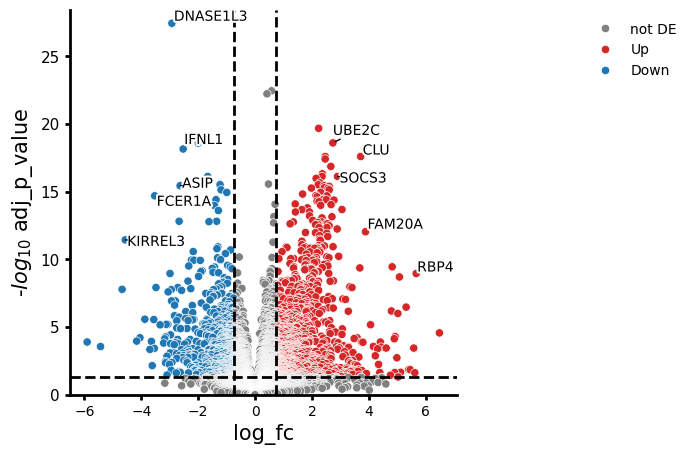

In [17]:
cc.plot_volcano("COVID_SEV_female_vs_HV_female", results_df=res_source_sex)

NaNs encountered, dropping rows with NaNs


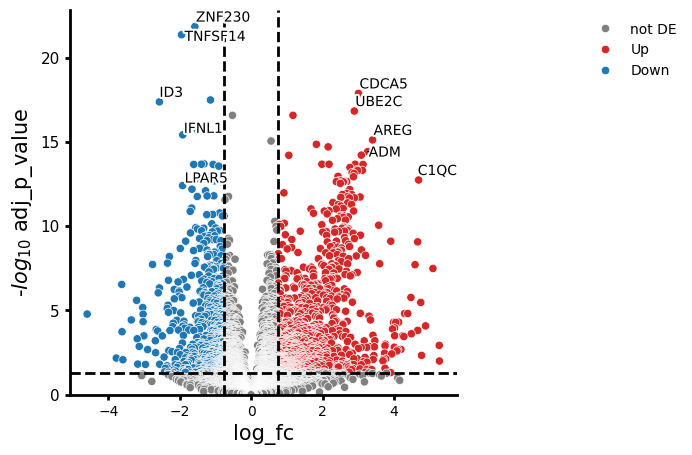

In [18]:
cc.plot_volcano("COVID_SEV_male_vs_HV_male", results_df=res_source_sex)

Comparing the two volcano plots, we can see whether men or women show a stronger or qualitatively different transcriptional response to severe COVID-19. Top hits appearing in both contrasts represent a robust, sex-independent COVID-19 signature; hits unique to one contrast suggest sex-dimorphic regulation. Both contrasts show a strong interferon response. Genes such as *IFI27* and *CDCA5* appear consistently at the top regardless of sex, suggesting a core COVID-19 transcriptional signature shared between men and women. We will formally test whether the response differs between sexes in Approach 2.

### Top DE genes

In [19]:
sig = res_cc_deseq2[res_cc_deseq2["adj_p_value"] < 0.05]
(
    sig
    .assign(abs_lfc=sig["log_fc"].abs())
    .sort_values("abs_lfc", ascending=False)
    [["variable", "log_fc", "adj_p_value", "contrast"]]
    .drop_duplicates(subset="variable")
    .head(20)
)

,variable,log_fc,adj_p_value,contrast
62669,NLGN4Y,6.938495,9.139796e-13,HV_male_vs_COVID_SEV_female
104790,IGHV7-4-1,6.479591,2.700344e-05,COVID_SEV_female_vs_HV_female
41625,PPP1R2C,-6.109462,5.559397e-16,COVID_SEV_male_vs_HV_female
63686,IGHV2-70D,-6.057814,2.458839e-06,HV_male_vs_COVID_SEV_female
63105,MT1M,-5.979759,1.507049e-08,HV_male_vs_COVID_SEV_female
42879,RPS4Y2,5.934048,8.287526e-03,COVID_SEV_male_vs_HV_female
41889,IGLV1-36,-5.910407,1.064951e-05,COVID_SEV_male_vs_HV_female
105075,NEBL,-5.901076,1.273689e-04,COVID_SEV_female_vs_HV_female
42196,CH25H,5.745514,3.765922e-04,COVID_SEV_male_vs_HV_female
41754,SCARA5,-5.676529,2.323386e-07,COVID_SEV_male_vs_HV_female


## 2. FactorialDE — single model on all samples

### Group encoding: shared dispersion, pairwise contrasts

A single model is fitted on all 30 donors. `EdgeR` estimates the mean-dispersion trend across all four condition groups simultaneously; `PyDESeq2` estimates size factors from all samples jointly. The pairwise contrasts are then extracted from this shared model.

This produces the same six contrasts as `ConditionComparison`, but because each contrast is derived from a model that saw all 30 samples rather than ~15, the dispersion estimates are more reliable and tests are more powerful.

#### EdgeR

In [20]:
res_fac_group_edger, model_fge = ptf.FactorialDE.run_once(
    pt.tl.EdgeR, pdata, condition_cols=condition_cols, encoding="group",
)

res_fac_group_edger[res_fac_group_edger["adj_p_value"] < 0.05].groupby("contrast")["variable"].count().sort_values(ascending=False)

• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model


contrast
COVID_SEV_female_vs_HV_male           5442
COVID_SEV_male_vs_HV_male             3710
COVID_SEV_female_vs_HV_female         2963
COVID_SEV_male_vs_HV_female           2553
COVID_SEV_female_vs_COVID_SEV_male      51
HV_female_vs_HV_male                    24
Name: variable, dtype: int64

#### PyDESeq2

In [21]:
res_fac_group_deseq2, model_fgd = ptf.FactorialDE.run_once(
    pt.tl.PyDESeq2, pdata, condition_cols=condition_cols, encoding="group",
)

res_fac_group_deseq2[res_fac_group_deseq2["adj_p_value"] < 0.05].groupby("contrast")["variable"].count().sort_values(ascending=False)

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 14.71 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 20.16 seconds.

Fitting LFCs...
... done in 11.88 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 107 outlier genes.

Fitting dispersions...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.14 seconds.

Fitting LFCs...
... done in 0.14 seconds.



contrast
COVID_SEV_female_vs_HV_male           5838
COVID_SEV_male_vs_HV_male             4286
COVID_SEV_female_vs_HV_female         3547
COVID_SEV_male_vs_HV_female           3251
COVID_SEV_female_vs_COVID_SEV_male     204
HV_female_vs_HV_male                    25
Name: variable, dtype: int64

The cross-condition contrasts (e.g. `COVID_SEV_female_vs_HV_male`) have the most significant genes because they conflate two biological signals at once: disease *and* sex. The within-sex disease contrasts (`COVID_SEV_female_vs_HV_female`, `COVID_SEV_male_vs_HV_male`) are more interpretable: they isolate the disease effect while holding sex constant. The pure sex contrasts (`COVID_SEV_female_vs_COVID_SEV_male`, `HV_female_vs_HV_male`) are expected to be small, driven mainly by sex-chromosome genes.

#### Volcano plots from the shared-dispersion model

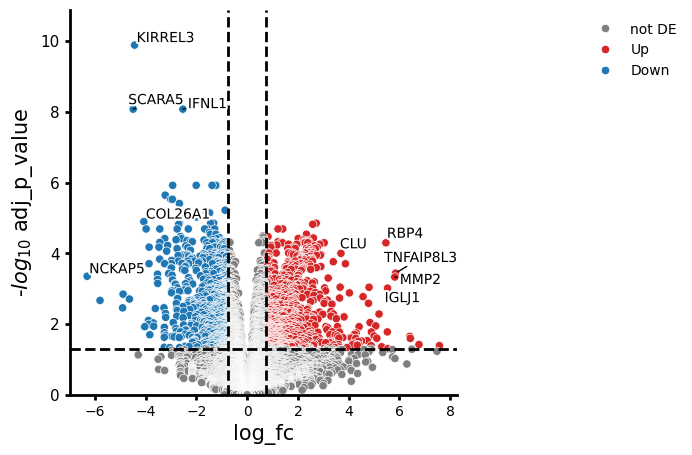

In [22]:
fc_group = ptf.FactorialDE(pt.tl.EdgeR)
fc_group.model_ = model_fge
fc_group.plot_volcano("COVID_SEV_female_vs_HV_female", results_df=res_fac_group_edger)

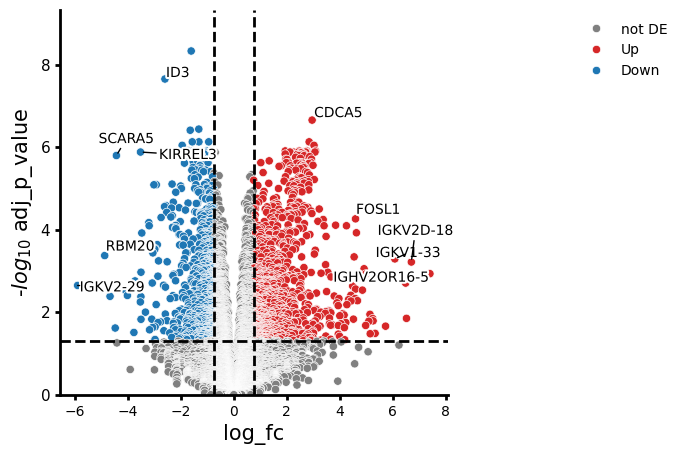

In [23]:
fc_group.plot_volcano("COVID_SEV_male_vs_HV_male", results_df=res_fac_group_edger)

### Interaction encoding: formal sex-dimorphism test

The group encoding above tells us how many genes differ between specific condition pairs. It cannot tell us whether the *COVID-19 effect itself* is different between sexes.

For that we fit `~ Source + Sex + Source:Sex`. The interaction coefficient `Source:Sex` is the answer to the question: **is the transcriptional response to COVID-19 significantly different in men compared to women?** A gene is significant in this term if and only if its COVID-vs-HV fold change differs between the sexes.

We set `ref_levels` so that the main effects are immediately interpretable: `Source[T.COVID_SEV]` gives the disease effect in women, `Sex[T.male]` gives the sex effect in healthy donors, and `Source[T.COVID_SEV]:Sex[T.male]` gives the *additional* disease effect in men beyond what is seen in women.

#### EdgeR

In [24]:
res_fac_inter_edger, model_fie = ptf.FactorialDE.run_once(
    pt.tl.EdgeR,
    pdata,
    condition_cols=condition_cols,
    encoding="interaction",
    ref_levels={"Source": "HV", "Sex": "female"},
)

for c in res_fac_inter_edger["contrast"].unique():
    n_sig = res_fac_inter_edger.query("contrast == @c")["adj_p_value"].lt(0.05).sum()
    print(f"  {c:55s}  {n_sig:5d} sig. genes")

• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
  Intercept                                                18450 sig. genes
  Source[T.COVID_SEV]                                       2963 sig. genes
  Sex[T.male]                                                 24 sig. genes
  Source[T.COVID_SEV]:Sex[T.male]                              0 sig. genes


#### PyDESeq2

In [25]:
res_fac_inter_deseq2, model_fid = ptf.FactorialDE.run_once(
    pt.tl.PyDESeq2,
    pdata,
    condition_cols=condition_cols,
    encoding="interaction",
    ref_levels={"Source": "HV", "Sex": "female"},
)

for c in res_fac_inter_deseq2["contrast"].unique():
    n_sig = res_fac_inter_deseq2.query("contrast == @c")["adj_p_value"].lt(0.05).sum()
    print(f"  {c:55s}  {n_sig:5d} sig. genes")

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 14.87 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 23.50 seconds.

Fitting LFCs...
... done in 11.27 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 107 outlier genes.

Fitting dispersions...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.14 seconds.

Fitting LFCs...
... done in 0.14 seconds.



  Source[T.COVID_SEV]                                       3543 sig. genes
  Sex[T.male]                                                 25 sig. genes
  Source[T.COVID_SEV]:Sex[T.male]                              0 sig. genes


The interaction term `Source[T.COVID_SEV]:Sex[T.male]` has 0 significant genes
at FDR < 0.05, while the main disease effect `Source[T.COVID_SEV]` has 2,963.
This means the COVID-19 transcriptional response is largely **shared between
sexes** in this cohort. Men and women show the same genes going up and down.
The sex effect in healthy donors (`Sex[T.male]`) is minimal (24 genes), as
expected, mostly sex-chromosome genes.

Note that this conclusion is specific to this subsampled cohort of 30 donors.
Running on the full COMBAT dataset may reveal subtle sex-dimorphic effects that
lack power here.